In [1]:
import pandas as pd 
import numpy as np  

import matplotlib.pyplot as pyplot
import seaborn as sns

In [2]:
results_data=pd.read_csv(r"C:\Users\HEMANATH\Desktop\Fifa Match\data\raw\results.csv")
results_data

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False
...,...,...,...,...,...,...,...,...,...
49472,2026-06-27,Jordan,Argentina,NaN,NaN,FIFA World Cup,Arlington,United States,True
49473,2026-06-27,Colombia,Portugal,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True
49474,2026-06-27,DR Congo,Uzbekistan,NaN,NaN,FIFA World Cup,Atlanta,United States,True
49475,2026-06-27,Panama,England,NaN,NaN,FIFA World Cup,East Rutherford,United States,True


In [5]:
results_data.shape

(49477, 11)

In [6]:
results_data.isna().sum()

date           0
home_team      0
away_team      0
home_score    60
away_score    60
tournament     0
city           0
country        0
neutral        0
year           0
month          0
dtype: int64

In [7]:
results_data.dtypes

date          datetime64[ns]
home_team             object
away_team             object
home_score           float64
away_score           float64
tournament            object
city                  object
country               object
neutral                 bool
year                   int32
month                  int32
dtype: object

In [3]:
results_data.columns

Index(['date', 'home_team', 'away_team', 'home_score', 'away_score',
       'tournament', 'city', 'country', 'neutral'],
      dtype='object')

In [4]:
results_data['date']=pd.to_datetime(results_data['date'])

results_data['year']=results_data['date'].dt.year
results_data['month']=results_data['date'].dt.month

results_data[['date','year','month']].head()

,date,year,month
0,1872-11-30,1872,11
1,1873-03-08,1873,3
2,1874-03-07,1874,3
3,1875-03-06,1875,3
4,1876-03-04,1876,3


In [8]:
def get_results(row):
    if row['home_score']>row['away_score']:
        return 0
    elif row['home_score']<row['away_score']:
        return 2
    else:
        return 1
    
results_data['result']=results_data.apply(get_results,axis=1)

In [9]:
results_data.dropna(subset=['home_score','away_score'],inplace=True)

In [10]:
results_data.isna().sum()

date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
city          0
country       0
neutral       0
year          0
month         0
result        0
dtype: int64

In [11]:
results_data.dtypes

date          datetime64[ns]
home_team             object
away_team             object
home_score           float64
away_score           float64
tournament            object
city                  object
country               object
neutral                 bool
year                   int32
month                  int32
result                 int64
dtype: object

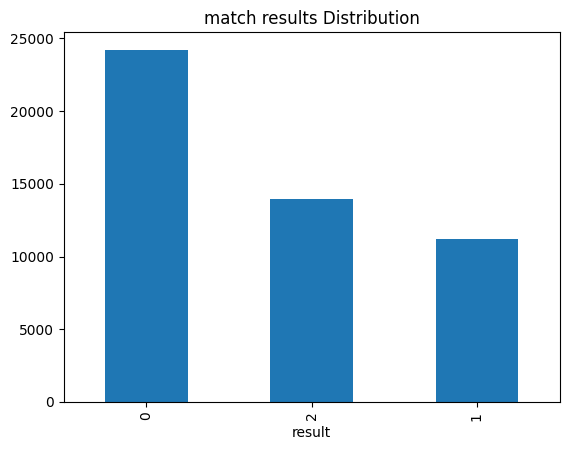

In [12]:
import matplotlib.pyplot as plt
results_data['result'].value_counts().plot(kind='bar',title='match results Distribution')
plt.show()

In [15]:
results_data.to_csv(r"C:\Users\HEMANATH\Desktop\Fifa Match\data\processed\clean_matches.csv", index=False)